In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
onehot= OneHotEncoder(handle_unknown= "ignore", sparse_output=False)
scaler=StandardScaler()
from sklearn.model_selection import train_test_split

In [2]:
data= pd.read_csv("drug200.csv")

In [3]:
data["Drug"].value_counts()

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [5]:
x= data.drop(columns=["Drug"])
y= data["Drug"].copy()

In [6]:
sex= onehot.fit_transform(x[["Sex"]])
sex= pd.DataFrame(sex, columns= onehot.get_feature_names_out(["Sex"]))
x= pd.concat([x,sex], axis=1)
bp= onehot.fit_transform(x[["BP"]])
bp= pd.DataFrame(bp, columns= onehot.get_feature_names_out(["BP"]))
x= pd.concat([x,bp], axis=1)
cholesterol= onehot.fit_transform(x[["Cholesterol"]])
cholesterol= pd.DataFrame(cholesterol, columns= onehot.get_feature_names_out(["Cholesterol"]))
x= pd.concat([x,cholesterol], axis=1)
x.drop(columns=["Sex", "BP", "Cholesterol"], inplace=True)

In [7]:
x

,Age,Na_to_K,Sex_F,Sex_M,BP_HIGH,BP_LOW,BP_NORMAL,Cholesterol_HIGH,Cholesterol_NORMAL
0,23,25.355,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,47,13.093,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,47,10.114,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,28,7.798,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4,61,18.043,1.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
195,56,11.567,1.0,0.0,0.0,1.0,0.0,1.0,0.0
196,16,12.006,0.0,1.0,0.0,1.0,0.0,1.0,0.0
197,52,9.894,0.0,1.0,0.0,0.0,1.0,1.0,0.0
198,23,14.020,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [8]:
from keras.layers import Dense, Input, Flatten, Dropout
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score

In [10]:
model= Sequential([
    Input(shape=(9,)),
    Dense(7, activation="relu"),
    Dropout(0.3),
    Dense(5, activation="softmax")
])

In [11]:
model.compile(
    optimizer="Adam",
    loss= "categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
y_train.shape, y_test.shape

((160,), (40,))

In [14]:
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.fit_transform(x_test)

In [15]:
y_train= pd.DataFrame(y_train, columns=["Drug"], index=y_train.index)

In [16]:
y_train_encoded= onehot.fit_transform(y_train)
y_train_encoded

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0.],
       [0., 1.

In [17]:
callback= EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    verbose=1
)

In [18]:
history= model.fit(x_train_scaled, y_train_encoded, epochs=150, callbacks=callback, validation_split=0.2, batch_size=2)

Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2891 - loss: 1.7331 - val_accuracy: 0.2500 - val_loss: 1.7188
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3594 - loss: 1.6347 - val_accuracy: 0.2812 - val_loss: 1.5839
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4141 - loss: 1.4841 - val_accuracy: 0.4375 - val_loss: 1.4876
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3984 - loss: 1.4657 - val_accuracy: 0.4688 - val_loss: 1.4083
Epoch 5/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4844 - loss: 1.3665 - val_accuracy: 0.5000 - val_loss: 1.3422
Epoch 6/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4141 - loss: 1.3592 - val_accuracy: 0.5312 - val_loss: 1.2878
Epoch 7/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5469 - loss: 1.2685 - val_accuracy: 0.5625 - val_loss: 1.2393
Epoch 8/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5547 - loss: 1.2677 - val_accuracy: 0.6250 - v

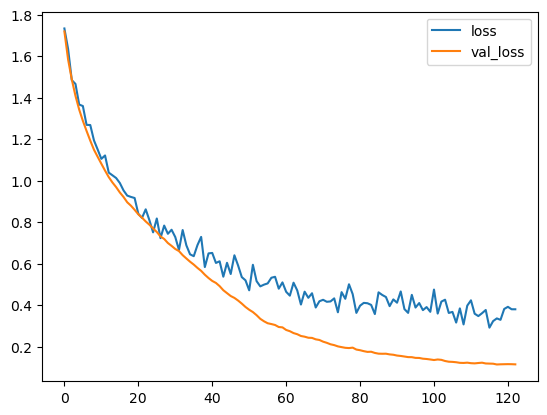

In [19]:
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()

In [20]:
y_pred_prob= model.predict(x_test_scaled)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [22]:
y_pred_indices= np.argmax(y_pred_prob, axis=1)
y_pred= onehot.categories_[0][y_pred_indices]

In [23]:
accuracy_score(y_test, y_pred)

0.975

In [25]:
def model_accuracy(y_pred, y_test):    
    count=0
    for i in range(len(y_test)):
        if y_pred[i]==y_test.iloc[i]:
            count+=1
    acc= float((count/len(y_test))*100)
    return acc

In [26]:
m_accuracy=model_accuracy(y_pred, y_test)
m_accuracy

97.5